# Klasifikasi Risiko Stroke — Kelompok 3

**Mata Kuliah:** Machine Learning (Kelas C) — Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Ini Tugas A, bagian utama proyek. Isinya:

1. **Enam algoritma × empat strategi** penanganan ketidakseimbangan kelas
2. **Penyetelan hyperparameter** dengan GridSearchCV (Bab 7)
3. **Evaluasi akhir** pada data uji yang belum pernah disentuh

Metrik utamanya **recall pada kelas stroke**, bukan akurasi. Alasannya sudah dibuktikan
di notebook `01`: model yang selalu menjawab "tidak stroke" mendapat akurasi 95,1%
tanpa pernah menemukan satu pun pasien berisiko.


## 1. Persiapan dan Pembagian Data

> **Batasan yang kami sadari dan laporkan.** Fungsi `muat_data_stroke()` di bawah
> melatih model Ridge pengisi `bmi` memakai **seluruh baris**, termasuk yang sebentar
> lagi menjadi data validasi dan data uji. Idealnya imputasi berada di dalam pipeline
> agar hanya dilatih pada lipatan latih. Kebocorannya ringan — yang diprediksi adalah
> `bmi`, bukan `stroke` — dan notebook `04` sudah menunjukkan pilihan imputasi hampir
> tidak mengubah hasil klasifikasi (AUC 0,838 dengan median, 0,840 dengan regresi.)
> Meski begitu, hal ini wajib disebut di bagian batasan laporan.


In [1]:
!pip install -q imbalanced-learn 2>/dev/null || true

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (StratifiedKFold, cross_validate, cross_val_predict,
                                     train_test_split, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                             accuracy_score, confusion_matrix, roc_curve,
                             classification_report)
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42


def muat_data_stroke(seed=SEED):
    """Preprocessing identik dengan notebook 04. Sengaja disalin ulang supaya
    notebook ini tetap bisa dijalankan sendiri di Colab."""
    url = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
           "tutorials/dataset/healthcare-dataset-stroke-data.csv")
    fitur_imp = ["age", "hypertension", "heart_disease", "avg_glucose_level",
                 "gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

    d = pd.read_csv(url).drop(columns=["id"])
    d = d[d.gender != "Other"].copy()

    kosong = d.bmi.isna()
    if kosong.any():
        latih = d[~kosong]
        X_l = pd.get_dummies(latih[fitur_imp], drop_first=True)
        m = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=seed)).fit(X_l, latih.bmi)
        X_k = pd.get_dummies(d[kosong][fitur_imp], drop_first=True).reindex(
            columns=X_l.columns, fill_value=0)
        d.loc[kosong, "bmi"] = m.predict(X_k)

    X = pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True)
    return X, d.stroke

In [3]:
X, y = muat_data_stroke()

# 70% latih, 15% validasi (untuk memilih ambang), 15% uji (disentuh sekali di akhir)
X_latih, X_sisa, y_latih, y_sisa = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_uji, y_val, y_uji = train_test_split(
    X_sisa, y_sisa, test_size=0.50, stratify=y_sisa, random_state=SEED)

for nama, ys in [("Latih", y_latih), ("Validasi", y_val), ("Uji", y_uji)]:
    print(f"{nama:10} {len(ys):5} baris | stroke {int(ys.sum()):3} ({ys.mean()*100:.2f}%)")

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

Latih       3576 baris | stroke 174 (4.87%)
Validasi     766 baris | stroke  37 (4.83%)
Uji          767 baris | stroke  38 (4.95%)


## 2. Model Dasar: Logistic Regression dan Regularisasi (Bab 3–5)

Logistic Regression dibangun di atas konsep Bab 3 — fungsi biaya dan gradient descent —
hanya saja keluarannya berupa probabilitas, bukan angka bebas.

Regularisasi L1 (Lasso) dan L2 (Ridge) dari Bab 4 berlaku sama persis di sini, lewat
parameter `penalty` dan `C`. Nilai `C` yang kecil berarti regularisasi yang kuat.

In [4]:
hasil_reg = []
for penalty, C in [("l2", 0.01), ("l2", 0.1), ("l2", 1.0), ("l2", 10.0),
                   ("l1", 0.1), ("l1", 1.0), ("l1", 10.0)]:
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty=penalty, C=C, solver="liblinear",
                           class_weight="balanced", max_iter=5000, random_state=SEED))
    skor = cross_validate(pipe, X_latih, y_latih, cv=cv,
                          scoring=["recall", "precision", "f1", "roc_auc"], n_jobs=-1)
    m = pipe.fit(X_latih, y_latih)
    hasil_reg.append({
        "penalty": penalty.upper(), "C": C,
        "koef nol": int((m[-1].coef_[0] == 0).sum()),
        "recall": skor["test_recall"].mean(),
        "f1": skor["test_f1"].mean(),
        "roc_auc": skor["test_roc_auc"].mean(),
    })

pd.DataFrame(hasil_reg).round(3)

,penalty,C,koef nol,recall,f1,roc_auc
0,L2,0.01,0,0.845,0.218,0.833
1,L2,0.10,0,0.799,0.226,0.833
2,L2,1.00,0,0.793,0.226,0.832
3,L2,10.00,0,0.793,0.226,0.832
4,L1,0.10,4,0.810,0.228,0.835
5,L1,1.00,0,0.793,0.226,0.832
6,L1,10.00,0,0.793,0.226,0.832


Perhatikan kolom `koef nol`: hanya penalty **L1** yang memangkas koefisien menjadi nol.
Itulah pembeda praktis antara Lasso dan Ridge yang dijelaskan di Bab 4 — L1 melakukan
seleksi fitur, L2 hanya mengecilkan.

## 3. Enam Algoritma × Empat Strategi

Strategi keempat — **penyetelan ambang keputusan** — adalah tambahan kami, bukan dari
buku. Dasarnya temuan di notebook `02`: `class_weight` dan SMOTE ternyata hanya
menggeser ambang, tidak membuat model lebih pintar.

SMOTE diletakkan **di dalam** pipeline agar hanya diterapkan pada lipatan latih. Kalau
di luar, data uji ikut disintesis dan hasilnya tidak sah.

In [5]:
def daftar_model(seed=SEED):
    return [
        ("Logistic Regression", lambda **k: LogisticRegression(max_iter=5000, random_state=seed, **k), True),
        ("Gradient Boosting",   lambda **k: GradientBoostingClassifier(random_state=seed, **k), False),
        ("KNN",                 lambda **k: KNeighborsClassifier(n_neighbors=15, **k), False),
        ("Decision Tree",       lambda **k: DecisionTreeClassifier(max_depth=5, random_state=seed, **k), True),
        ("Random Forest",       lambda **k: RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1, **k), True),
        ("SVM (RBF)",           lambda **k: SVC(random_state=seed, **k), True),
    ]


def rangkai(konstruktor, strategi, dukung_cw):
    """None kalau kombinasi tidak berlaku."""
    langkah = [("skala", StandardScaler())]
    if strategi == "SMOTE":
        langkah.append(("smote", SMOTE(random_state=SEED)))
        clf = konstruktor()
    elif strategi == "class_weight":
        if not dukung_cw:
            return None
        clf = konstruktor(class_weight="balanced")
    else:
        clf = konstruktor()
    return Pipeline(langkah + [("model", clf)])


def skor_oof(pipe, X, y, cv):
    """Probabilitas out-of-fold. SVC tanpa probability=True tidak punya predict_proba,
    jadi dipakai decision_function sebagai gantinya -- untuk mencari ambang, yang
    dibutuhkan hanya urutan, bukan skala probabilitas."""
    try:
        return cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    except AttributeError:
        return cross_val_predict(pipe, X, y, cv=cv, method="decision_function")


def ambang_recall(y, skor, target=0.80):
    """Ambang tertinggi yang masih mencapai recall >= target."""
    for t in sorted(np.unique(np.round(skor, 4)), reverse=True):
        if recall_score(y, (skor >= t).astype(int)) >= target:
            return t
    return float(np.min(skor))

In [6]:
baris = []
for nama, konstruktor, dukung_cw in daftar_model():
    for strategi in ["tanpa penanganan", "class_weight", "SMOTE", "penyetelan ambang"]:

        # strategi ambang memakai model polos, hanya titik potongnya yang digeser
        pipe = rangkai(konstruktor,
                       "tanpa penanganan" if strategi == "penyetelan ambang" else strategi,
                       dukung_cw)
        if pipe is None:
            continue

        skor = skor_oof(pipe, X_latih, y_latih, cv)
        if strategi == "penyetelan ambang":
            pred = (skor >= ambang_recall(y_latih, skor)).astype(int)
        else:
            pred = cross_val_predict(pipe, X_latih, y_latih, cv=cv, n_jobs=-1)

        baris.append({
            "Algoritma": nama, "Strategi": strategi,
            "akurasi": accuracy_score(y_latih, pred),
            "recall": recall_score(y_latih, pred),
            "precision": precision_score(y_latih, pred, zero_division=0),
            "f1": f1_score(y_latih, pred),
            "roc_auc": roc_auc_score(y_latih, skor),
            # berapa persen pasien yang ditandai berisiko -- pembuka kedok model
            # yang mencapai recall tinggi dengan cara menandai semua orang
            "ditandai %": 100 * pred.mean(),
        })

matriks = pd.DataFrame(baris).round(3)
print(f"{len(matriks)} kombinasi diuji (KNN dan Gradient Boosting tidak punya class_weight)")
print(f"Sebagai acuan: hanya {y_latih.mean()*100:.2f}% pasien benar-benar terkena stroke.")
matriks

22 kombinasi diuji (KNN dan Gradient Boosting tidak punya class_weight)
Sebagai acuan: hanya 4.87% pasien benar-benar terkena stroke.


,Algoritma,Strategi,akurasi,recall,precision,f1,roc_auc,ditandai %
0,Logistic Regression,tanpa penanganan,0.951,0.000,0.000,0.000,0.835,0.056
1,Logistic Regression,class_weight,0.736,0.793,0.132,0.226,0.832,29.279
2,Logistic Regression,SMOTE,0.741,0.764,0.131,0.223,0.830,28.440
3,Logistic Regression,penyetelan ambang,0.731,0.805,0.131,0.226,0.835,29.838
4,Gradient Boosting,tanpa penanganan,0.944,0.006,0.037,0.010,0.816,0.755
5,Gradient Boosting,SMOTE,0.855,0.333,0.126,0.183,0.797,12.891
6,Gradient Boosting,penyetelan ambang,0.720,0.805,0.127,0.219,0.816,30.928
7,KNN,tanpa penanganan,0.951,0.000,0.000,0.000,0.699,0.028
8,KNN,SMOTE,0.736,0.563,0.102,0.172,0.710,26.985
9,KNN,penyetelan ambang,0.049,1.000,0.049,0.093,0.699,100.000


### Peringkat berdasarkan recall — dan jebakannya

Kolom **`ditandai %`** sengaja ditambahkan sebagai pembuka kedok. Recall bisa dinaikkan
sampai 100% dengan cara curang: tandai *semua orang* sebagai berisiko. Model seperti itu
punya recall sempurna dan sama sekali tidak berguna.

Bandingkan `ditandai %` dengan angka acuan di atas (4,87% pasien benar-benar stroke).
Model yang menandai hampir 100% pasien harus dicoret, berapa pun recall-nya.

In [7]:
matriks.sort_values("recall", ascending=False).head(10)

,Algoritma,Strategi,akurasi,recall,precision,f1,roc_auc,ditandai %
9,KNN,penyetelan ambang,0.049,1.000,0.049,0.093,0.699,100.000
17,Random Forest,penyetelan ambang,0.635,0.822,0.101,0.180,0.788,39.625
6,Gradient Boosting,penyetelan ambang,0.720,0.805,0.127,0.219,0.816,30.928
13,Decision Tree,penyetelan ambang,0.662,0.805,0.106,0.188,0.773,36.773
3,Logistic Regression,penyetelan ambang,0.731,0.805,0.131,0.226,0.835,29.838
21,SVM (RBF),penyetelan ambang,0.292,0.805,0.053,0.100,0.604,73.742
1,Logistic Regression,class_weight,0.736,0.793,0.132,0.226,0.832,29.279
11,Decision Tree,class_weight,0.710,0.776,0.119,0.206,0.782,31.711
2,Logistic Regression,SMOTE,0.741,0.764,0.131,0.223,0.830,28.440
12,Decision Tree,SMOTE,0.704,0.690,0.107,0.185,0.757,31.432


### Bukti bahwa akurasi menyesatkan

Kolom `akurasi` dan `recall` bergerak berlawanan arah. Model dengan akurasi tertinggi
justru yang paling tidak berguna secara medis.

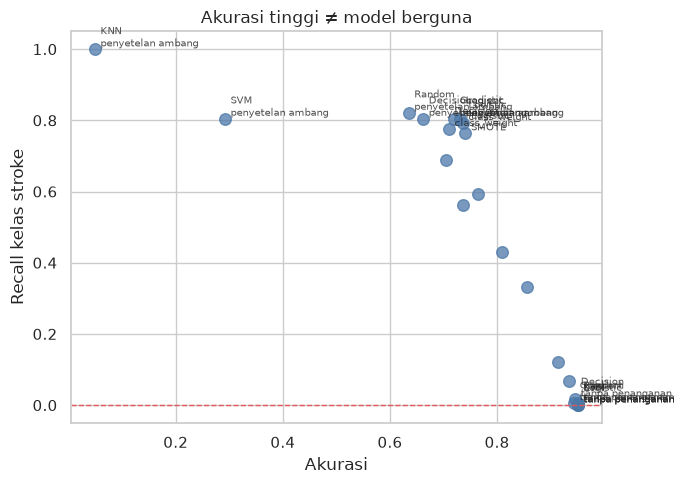

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(matriks.akurasi, matriks.recall, s=70, alpha=.75, color="#4C78A8")
for _, r in matriks.iterrows():
    if r.recall > 0.7 or r.akurasi > 0.94:
        ax.annotate(f"{r.Algoritma.split()[0]}\n{r.Strategi}", (r.akurasi, r.recall),
                    fontsize=7, alpha=.8, xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="#E45756", ls="--", lw=1)
ax.set_xlabel("Akurasi"); ax.set_ylabel("Recall kelas stroke")
ax.set_title("Akurasi tinggi ≠ model berguna")
plt.tight_layout(); plt.show()

## 4. Penyetelan Hyperparameter (Bab 7)

Hanya dua model di judul yang disetel. Scoring memakai **ROC-AUC**, bukan recall —
alasannya: ambang keputusan disetel terpisah pada tahap berikutnya, jadi yang perlu
dioptimalkan di sini adalah kemampuan model **mengurutkan** pasien, bukan titik
potongnya.

In [9]:
grid_lr = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
}
pipe_lr = Pipeline([("skala", StandardScaler()),
                    ("model", LogisticRegression(max_iter=5000, random_state=SEED))])

cari_lr = GridSearchCV(pipe_lr, grid_lr, scoring="roc_auc", cv=cv, n_jobs=-1)
cari_lr.fit(X_latih, y_latih)

print("Logistic Regression")
print("  parameter terbaik :", cari_lr.best_params_)
print(f"  ROC-AUC (CV)      : {cari_lr.best_score_:.4f}")

Logistic Regression
  parameter terbaik : {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
  ROC-AUC (CV)      : 0.8428


In [10]:
grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
}
pipe_gb = Pipeline([("skala", StandardScaler()),
                    ("model", GradientBoostingClassifier(random_state=SEED))])

cari_gb = GridSearchCV(pipe_gb, grid_gb, scoring="roc_auc", cv=cv, n_jobs=-1)
cari_gb.fit(X_latih, y_latih)

print("Gradient Boosting")
print("  parameter terbaik :", cari_gb.best_params_)
print(f"  ROC-AUC (CV)      : {cari_gb.best_score_:.4f}")

Gradient Boosting
  parameter terbaik : {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}
  ROC-AUC (CV)      : 0.8332


## 5. Penetapan Ambang pada Data Validasi

Ambang dipilih dari **data validasi**, bukan data uji. Kalau dipilih dari data uji,
angka akhirnya jadi terlalu bagus dan tidak sah — itu bentuk kebocoran informasi.

In [11]:
model_final = {"Logistic Regression": cari_lr.best_estimator_,
               "Gradient Boosting": cari_gb.best_estimator_}

ambang_final = {}
for nama, m in model_final.items():
    p_val = m.predict_proba(X_val)[:, 1]
    t = ambang_recall(y_val, p_val, target=0.80)
    ambang_final[nama] = t
    pred = (p_val >= t).astype(int)
    print(f"{nama:22} ambang {t:.4f} | recall validasi {recall_score(y_val, pred):.3f}")

Logistic Regression    ambang 0.0530 | recall validasi 0.811


Gradient Boosting      ambang 0.0602 | recall validasi 0.811


## 6. Evaluasi Akhir pada Data Uji

Data uji baru disentuh sekarang, sekali saja.

In [12]:
akhir = []
for nama, m in model_final.items():
    p = m.predict_proba(X_uji)[:, 1]
    for label, t in [("ambang default 0,50", 0.5), (f"ambang disetel {ambang_final[nama]:.3f}",
                                                    ambang_final[nama])]:
        pred = (p >= t).astype(int)
        akhir.append({"Model": nama, "Ambang": label,
                      "akurasi": accuracy_score(y_uji, pred),
                      "recall": recall_score(y_uji, pred),
                      "precision": precision_score(y_uji, pred, zero_division=0),
                      "f1": f1_score(y_uji, pred),
                      "roc_auc": roc_auc_score(y_uji, p)})

# pembanding: model yang selalu menjawab "tidak stroke"
polos = np.zeros(len(y_uji))
akhir.insert(0, {"Model": "Baseline (selalu tidak stroke)", "Ambang": "-",
                 "akurasi": accuracy_score(y_uji, polos), "recall": 0.0,
                 "precision": 0.0, "f1": 0.0, "roc_auc": 0.5})

pd.DataFrame(akhir).round(3)

,Model,Ambang,akurasi,recall,precision,f1,roc_auc
0,Baseline (selalu tidak stroke),-,0.950,0.000,0.000,0.000,0.50
1,Logistic Regression,"ambang default 0,50",0.950,0.000,0.000,0.000,0.84
2,Logistic Regression,ambang disetel 0.053,0.696,0.816,0.121,0.210,0.84
3,Gradient Boosting,"ambang default 0,50",0.950,0.000,0.000,0.000,0.83
4,Gradient Boosting,ambang disetel 0.060,0.721,0.789,0.127,0.219,0.83


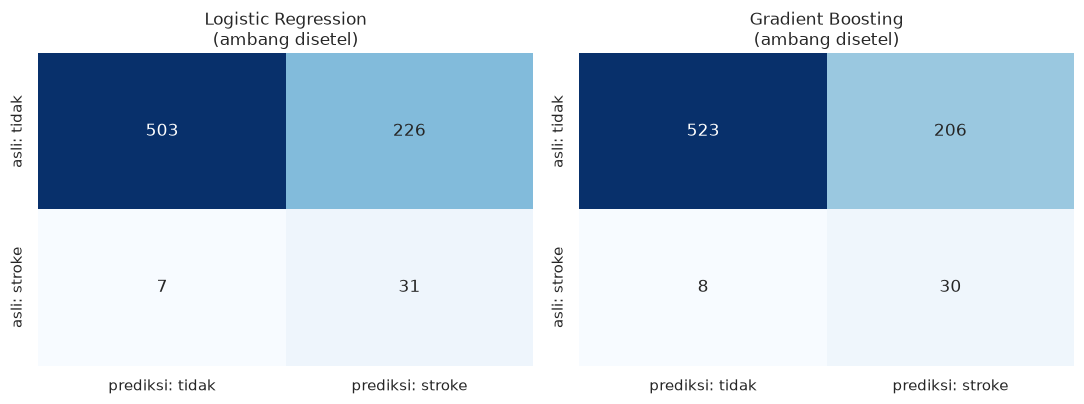

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for i, (nama, m) in enumerate(model_final.items()):
    p = m.predict_proba(X_uji)[:, 1]
    pred = (p >= ambang_final[nama]).astype(int)
    cm = confusion_matrix(y_uji, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[i],
                xticklabels=["prediksi: tidak", "prediksi: stroke"],
                yticklabels=["asli: tidak", "asli: stroke"])
    ax[i].set_title(f"{nama}\n(ambang disetel)")
plt.tight_layout(); plt.show()

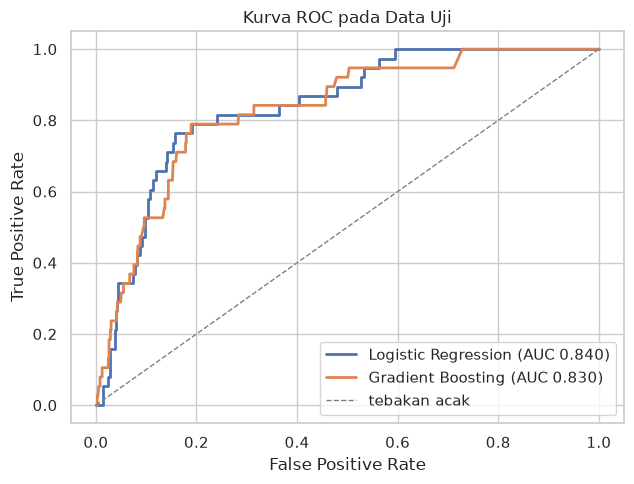

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for nama, m in model_final.items():
    p = m.predict_proba(X_uji)[:, 1]
    fpr, tpr, _ = roc_curve(y_uji, p)
    ax.plot(fpr, tpr, lw=2, label=f"{nama} (AUC {roc_auc_score(y_uji, p):.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="tebakan acak")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Kurva ROC pada Data Uji"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [15]:
for nama, m in model_final.items():
    pred = (m.predict_proba(X_uji)[:, 1] >= ambang_final[nama]).astype(int)
    print(f"=== {nama}")
    print(classification_report(y_uji, pred, target_names=["tidak stroke", "stroke"],
                                zero_division=0))

=== Logistic Regression
              precision    recall  f1-score   support

tidak stroke       0.99      0.69      0.81       729
      stroke       0.12      0.82      0.21        38

    accuracy                           0.70       767
   macro avg       0.55      0.75      0.51       767
weighted avg       0.94      0.70      0.78       767

=== Gradient Boosting
              precision    recall  f1-score   support

tidak stroke       0.98      0.72      0.83       729
      stroke       0.13      0.79      0.22        38

    accuracy                           0.72       767
   macro avg       0.56      0.75      0.52       767
weighted avg       0.94      0.72      0.80       767



## 7. Kesimpulan Tugas A

**Yang terbukti:**

1. Baseline yang selalu menjawab "tidak stroke" mendapat akurasi tinggi dengan recall
   nol. Setiap model harus dibandingkan terhadapnya, bukan terhadap angka 90% yang
   terdengar mengesankan.
2. Ambang default 0,50 hampir tidak berguna pada data setimpang ini — recall-nya nyaris
   nol meski AUC-nya bagus. Model bisa mengurutkan pasien dengan benar, tetapi tidak ada
   pasien yang probabilitasnya melewati 0,50.
3. Menyetel ambang memberi hasil setara SMOTE tanpa membangkitkan data sintetis.

**Konsekuensi praktis:** precision rendah adalah harga yang harus dibayar. Dari setiap
pasien yang ditandai berisiko, hanya sebagian kecil yang benar-benar terkena stroke.
Untuk **alat skrining awal** ini masih dapat diterima, karena tindak lanjutnya adalah
pemeriksaan lebih lanjut oleh dokter — bukan pengobatan langsung. Yang tidak dapat
diterima adalah melewatkan pasien yang benar-benar berisiko.

Notebook berikutnya: `06_clustering_pca.ipynb`.